In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import networkx as nx
from pathlib import Path
import pandas as pd

from neural_reconstruction.algorithms.fragment_linking.linker import HierarchicalFragmentLinker
from neural_reconstruction.core.preprocessing import SkinAnalysisPipeline
from neural_reconstruction.core.topology import TopologyBuilder
from neural_reconstruction.core.pathfinding import PathFinder
from neural_reconstruction.algorithms.fragment_linking.utils import compute_vector_angle,is_direction_too_similar

import skimage as ski
# from skimage.measure import label
# from skimage.restoration import rolling_ball
from scipy.spatial import KDTree

from xgboost import XGBClassifier
import joblib


In [2]:
BASE_PATH = Path('/home/pony/projects/ienf_q/')
IMAGE_ID = 'S1616-2_a'
BASE_PATH = BASE_PATH / f'nas/jia/data/{IMAGE_ID}'

In [3]:
image      = cv2.imread(f'{BASE_PATH}/image.png',      cv2.IMREAD_COLOR_RGB)[:, :, 1]  # 只取綠色通道
mask       = cv2.imread(f'{BASE_PATH}/mask.png',       cv2.IMREAD_GRAYSCALE)
annotation = cv2.imread(f'{BASE_PATH}/weka.png', cv2.IMREAD_GRAYSCALE)

print(f'image      shape: {image.shape},      dtype: {image.dtype}')
print(f'mask       shape: {mask.shape},       dtype: {mask.dtype}')
print(f'annotation shape: {annotation.shape}, dtype: {annotation.dtype}')


image      shape: (2048, 7577),      dtype: uint8
mask       shape: (2048, 7577),       dtype: uint8
annotation shape: (2048, 7577), dtype: uint8


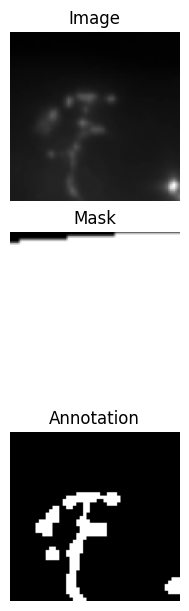

In [4]:
def crop(image:np.ndarray):
    x, y, w, h = 2800, 875 , 100, 100
    cropped_image = image[y:y+h, x:x+w]
    return cropped_image

roi_image = crop(image)
roi_mask = crop(mask)
roi_annotation = crop(annotation)
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
roi_annotation = cv2.morphologyEx(roi_annotation, cv2.MORPH_OPEN, kernel)

# apply closing to roi_annotation to fill small holes
roi_annotation = cv2.morphologyEx(roi_annotation, cv2.MORPH_CLOSE, kernel)
roi_annotation[roi_annotation > 0] = 255
# roi_annotation[roi_annotation <= 127] = 0

_, axes = plt.subplots(3, 1, figsize=(18, 6), constrained_layout=True)
axes[0].imshow(roi_image,      cmap='gray');  axes[0].set_title('Image');       axes[0].axis('off')
axes[1].imshow(roi_mask,       cmap='gray');  axes[1].set_title('Mask');        axes[1].axis('off')
axes[2].imshow(roi_annotation, cmap='gray');  axes[2].set_title('Annotation');  axes[2].axis('off')
plt.show()

In [5]:
builder = TopologyBuilder(segment_length=3.0)
skeleton = builder.build_skeleton_graph(roi_annotation, roi_image)

print(f'Nodes: {skeleton.number_of_nodes()}')
print(f'Edges: {skeleton.number_of_edges()}')
degrees = dict(skeleton.degree())
print(f'Endpoints (degree=1): {sum(1 for d in degrees.values() if d == 1)}')
print(f'Junctions (degree>=3): {sum(1 for d in degrees.values() if d >= 3)}')
print(f'Isolated  (degree=0): {sum(1 for d in degrees.values() if d == 0)}')

Nodes: 11
Edges: 7
Endpoints (degree=1): 8
Junctions (degree>=3): 2
Isolated  (degree=0): 1


/home/pony/projects/ienf_q/src/neural_reconstruction/core/topology/topology_builder.py:125: VisibleDeprecationWarning: separator in column name will change to _ in version 0.13; to silence this warning, use `separator='-'` to maintain current behavior and use `separator='_'` to switch to the new default behavior.
  summary = summarize(skel_obj)


In [6]:
def draw_graph_on_image(ax, graph, bg_image, title='', cmap='gray',
                        node_size=6, edge_alpha=0.8, color_by_distance=True):
    """Overlay a skeleton/seed graph on a background image."""
    ax.imshow(bg_image, cmap=cmap)
    ax.set_title(title)
    ax.axis('off')

    if graph.number_of_edges() == 0 and graph.number_of_nodes() == 0:
        return

    # --- edges ---
    if color_by_distance and graph.number_of_edges() > 0:
        distances = [d.get('branch-distance', 0) for _, _, d in graph.edges(data=True)]
        vmin, vmax = min(distances), max(distances)
        cmap_edge = plt.cm.plasma
        norm = plt.Normalize(vmin=vmin, vmax=max(vmax, 1e-6))

    for u, v, data in graph.edges(data=True):
        path = data.get('path', [u, v])
        ys = [p[0] for p in path]
        xs = [p[1] for p in path]
        if color_by_distance:
            color = cmap_edge(norm(data.get('branch-distance', 0)))
        else:
            color = 'cyan'
        ax.plot(xs, ys, color=color, linewidth=1.2, alpha=edge_alpha)

    # --- nodes: coloured by degree ---
    for node in graph.nodes():
        y, x = node
        deg = graph.degree(node)
        if deg == 0:
            color, zorder, size = 'yellow', 4, node_size * 1.5   # isolated
        elif deg == 1:
            color, zorder, size = 'red',    4, node_size          # endpoint
        elif deg == 2:
            color, zorder, size = 'lime',   3, node_size * 0.7   # chain (should be merged)
        else:
            color, zorder, size = 'blue',   5, node_size * 1.4   # junction
        ax.scatter(x, y, c=color, s=size**2, zorder=zorder, linewidths=0)

    # colorbar for edge distance
    if color_by_distance and graph.number_of_edges() > 0:
        sm = plt.cm.ScalarMappable(cmap=cmap_edge, norm=norm)
        sm.set_array([])
        plt.colorbar(sm, ax=ax, fraction=0.02, pad=0.01, label='branch-distance (px)')

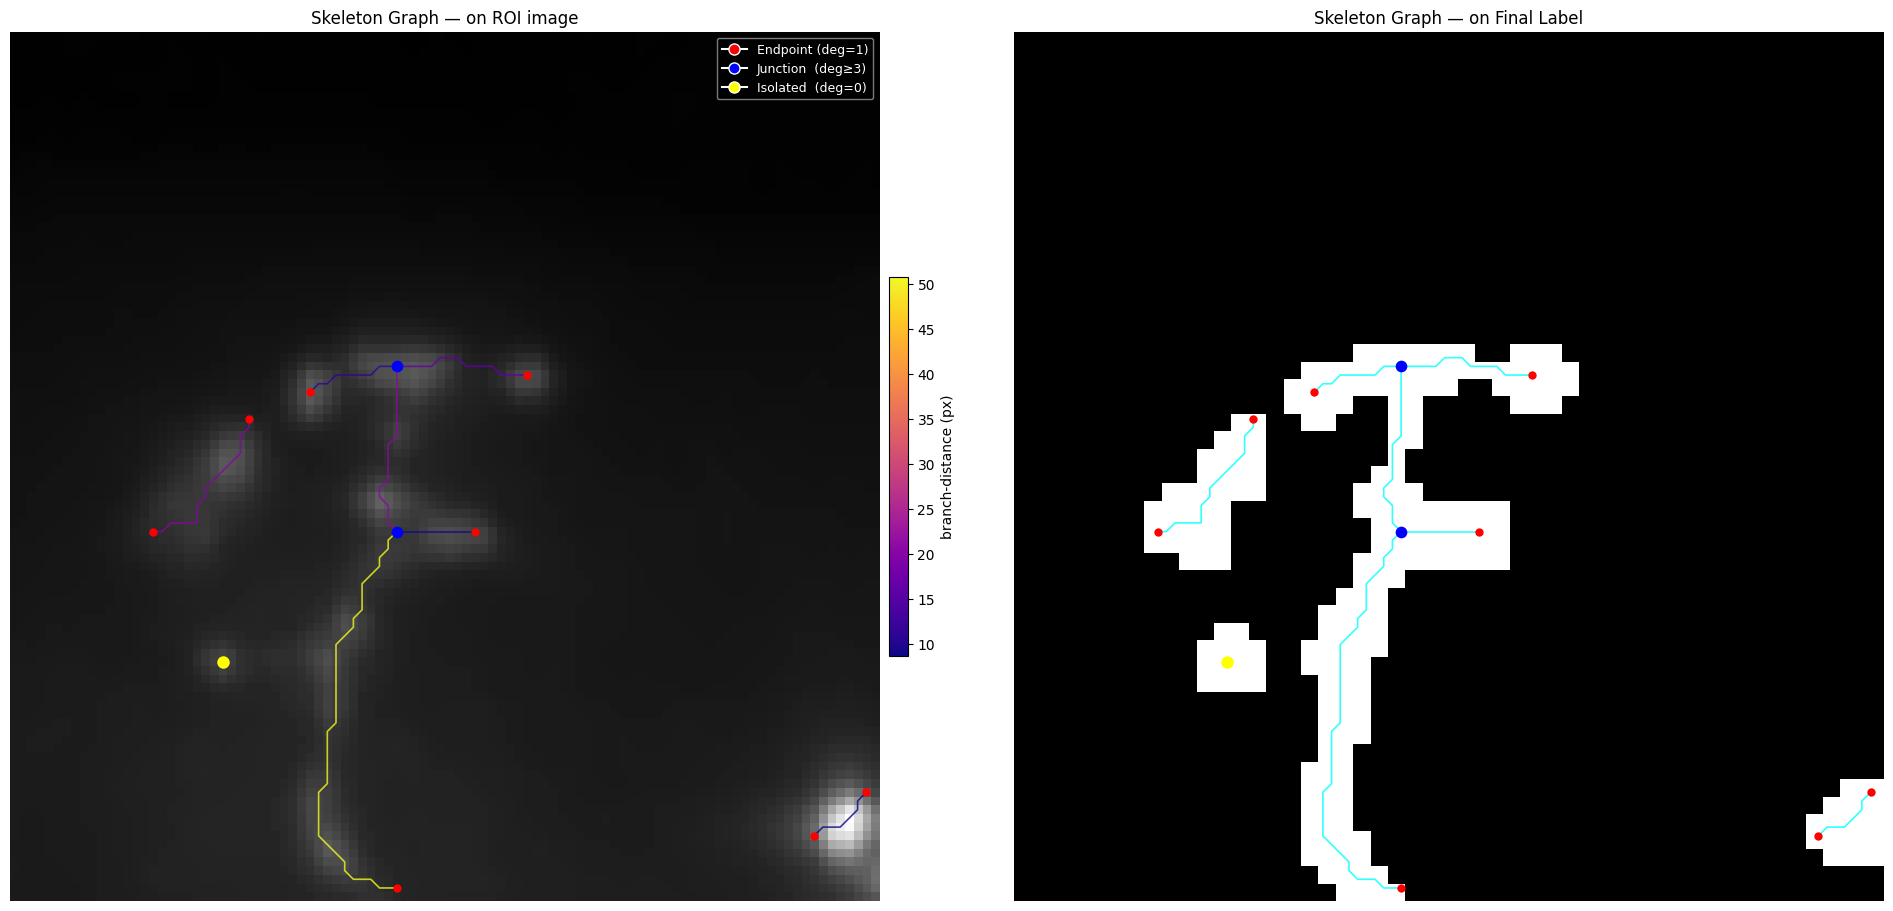

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(20, 9), constrained_layout=True)
draw_graph_on_image(axes[0], skeleton, roi_image,
                    title='Skeleton Graph — on ROI image', color_by_distance=True)
draw_graph_on_image(axes[1], skeleton, roi_annotation,
                    title='Skeleton Graph — on Final Label', color_by_distance=False)

# legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red',    markersize=8, label='Endpoint (deg=1)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue',   markersize=8, label='Junction  (deg≥3)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='yellow', markersize=8, label='Isolated  (deg=0)'),
]
axes[0].legend(handles=legend_elements, loc='upper right', fontsize=9,
               framealpha=0.6, facecolor='black', labelcolor='white')
plt.show()

In [8]:
seed = builder.build_seed_graph(roi_annotation , roi_image)

print(f'Skeleton → Seed')
print(f'  Nodes:  {skeleton.number_of_nodes():>5}  →  {seed.number_of_nodes()}')
print(f'  Edges:  {skeleton.number_of_edges():>5}  →  {seed.number_of_edges()}')
degrees = dict(seed.degree())
print(f'Endpoints (degree=1): {sum(1 for d in degrees.values() if d == 1)}')
print(f'Junctions (degree>=3): {sum(1 for d in degrees.values() if d >= 3)}')
print(f'Isolated  (degree=0): {sum(1 for d in degrees.values() if d == 0)}')

Skeleton → Seed
  Nodes:     11  →  45
  Edges:      7  →  41
Endpoints (degree=1): 8
Junctions (degree>=3): 2
Isolated  (degree=0): 1


/home/pony/projects/ienf_q/src/neural_reconstruction/core/topology/topology_builder.py:125: VisibleDeprecationWarning: separator in column name will change to _ in version 0.13; to silence this warning, use `separator='-'` to maintain current behavior and use `separator='_'` to switch to the new default behavior.
  summary = summarize(skel_obj)


In [9]:
cv2.imwrite(f'roi_image.png', roi_image)
cv2.imwrite(f'roi_annotation.png', roi_annotation)

import json
edeges = []
for u, v, data in seed.edges(data=True):
    # path = data.get('path', [u, v])
    edeges.append({
        'source': (int(u[0]), int(u[1])),
        'target': (int(v[0]), int(v[1])),
        "path": [tuple(int(coord) for coord in p) for p in data.get('path', [u, v])],
    })
nodes = []
for node, data in seed.nodes(data=True):
    nodes.append((int(node[0]), int(node[1])))
with open('seed_graph.json', 'w') as f:
    json.dump({'edges': edeges, 'nodes': nodes}, f)

In [10]:
read_graph = nx.Graph()
with open('seed_graph.json', 'r') as f:
    data = json.load(f)
    for node in data['nodes']:
        read_graph.add_node(tuple(node))
    for edge in data['edges']:
        read_graph.add_edge(tuple(edge['source']), tuple(edge['target']),
                            path=[tuple(coord) for coord in edge['path']],
                            )

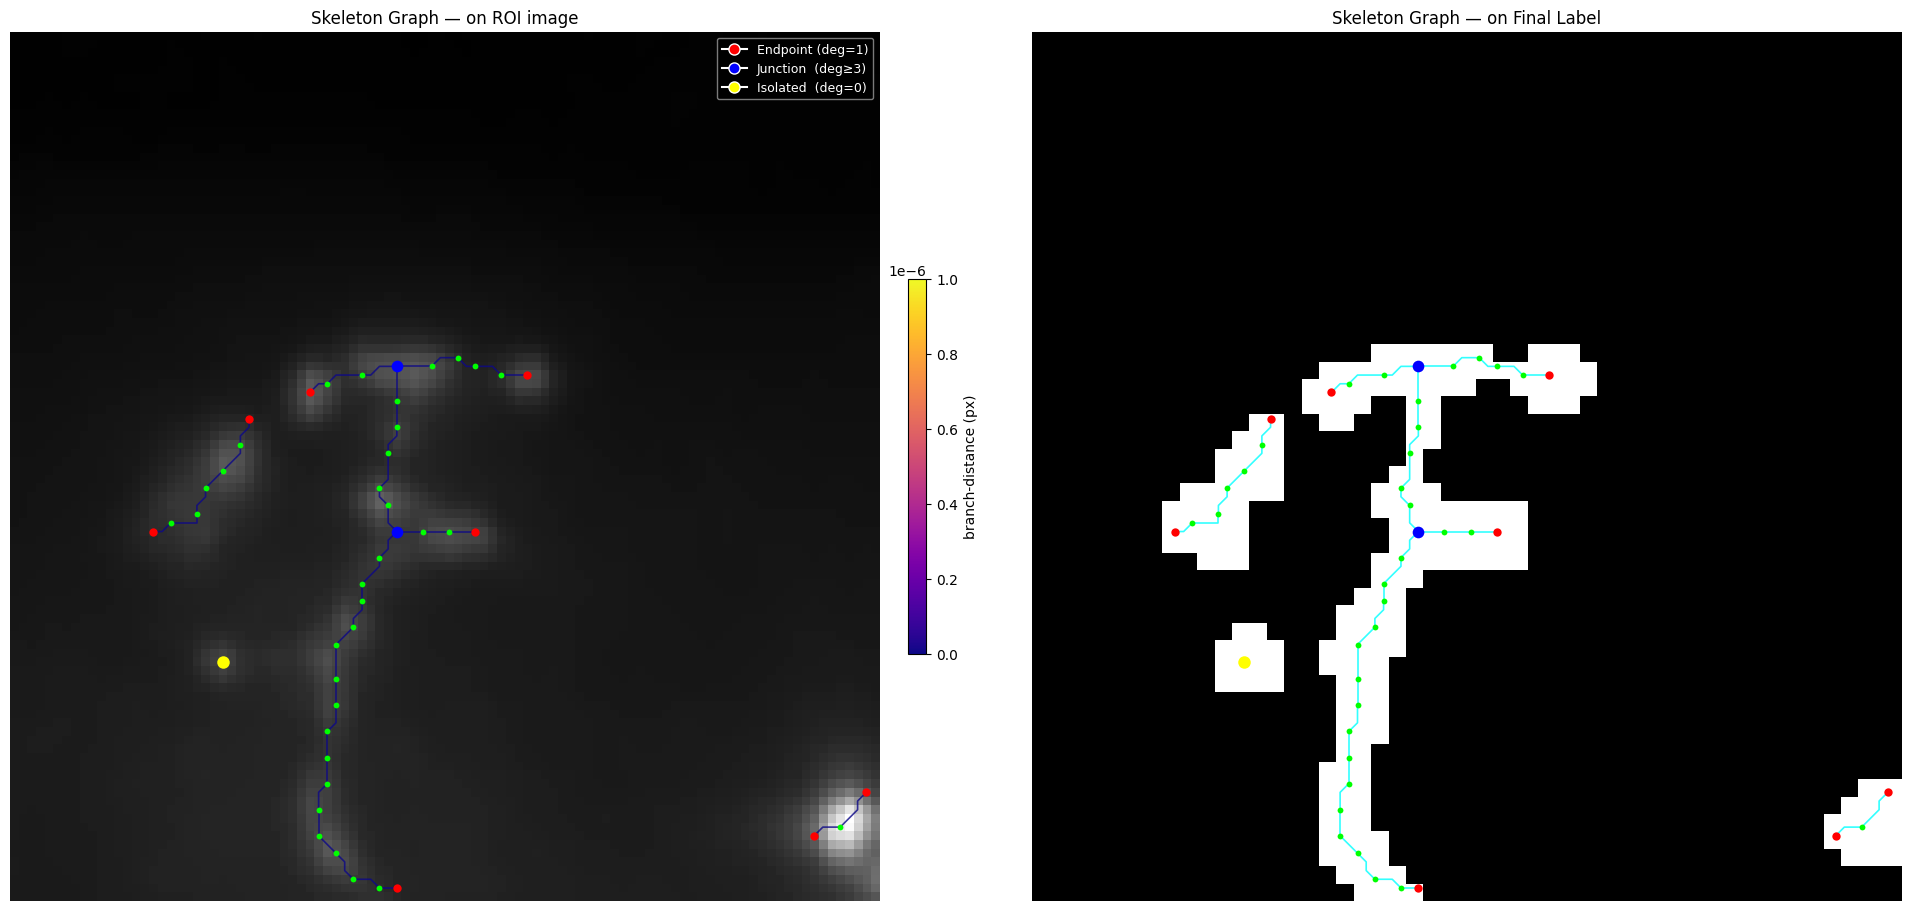

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(20, 9), constrained_layout=True)
draw_graph_on_image(axes[0], read_graph, roi_image,
                    title='Skeleton Graph — on ROI image', color_by_distance=True)
draw_graph_on_image(axes[1], read_graph, roi_annotation,
                    title='Skeleton Graph — on Final Label', color_by_distance=False)

# legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red',    markersize=8, label='Endpoint (deg=1)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue',   markersize=8, label='Junction  (deg≥3)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='yellow', markersize=8, label='Isolated  (deg=0)'),
]
axes[0].legend(handles=legend_elements, loc='upper right', fontsize=9,
               framealpha=0.6, facecolor='black', labelcolor='white')
plt.show()

In [12]:
# cost_map: bright pixels = low cost (prefer nerve fiber tissue)
cost_map = (255 - roi_image.astype(np.float32)) / 255.0
pathfinder = PathFinder(cost_map)

# Extract seed nodes as topology_points array
node_list = list(seed.nodes())
topology_points = np.array(node_list, dtype=np.int32)   # shape (N, 2), each row = (y, x)
kdtree = KDTree(topology_points)

print(f'Cost map shape: {cost_map.shape}, range: [{cost_map.min():.3f}, {cost_map.max():.3f}]')
print(f'Topology points: {len(topology_points)}')

Cost map shape: (100, 100), range: [0.122, 0.918]
Topology points: 45


# find_paths_from_source — Single Source to Multiple Targets

In [13]:
# Pick the first endpoint as source, query its 10 nearest neighbours as targets
source_node = next(n for n, d in seed.degree() if d == 1)
source = (int(source_node[0]), int(source_node[1]))

neighbor_idxs = kdtree.query_ball_point(source, r=40)
targets = [
    (int(topology_points[i][0]), int(topology_points[i][1]))
    for i in neighbor_idxs
    if tuple(topology_points[i]) != source
]

print(f'Source: {source}')
print(f'Targets ({len(targets)}): {targets[:5]} ...')

results = pathfinder.find_paths_from_source(source, targets)

found    = {t: v for t, v in results.items() if v is not None}
not_found = [t for t, v in results.items() if v is None]

print(f'\nFound:     {len(found)} / {len(targets)}')
print(f'Not found: {len(not_found)}')

Source: (41, 34)
Targets (33): [(40, 36), (68, 39), (56, 18), (44, 27), (57, 16)] ...

Found:     33 / 33
Not found: 0


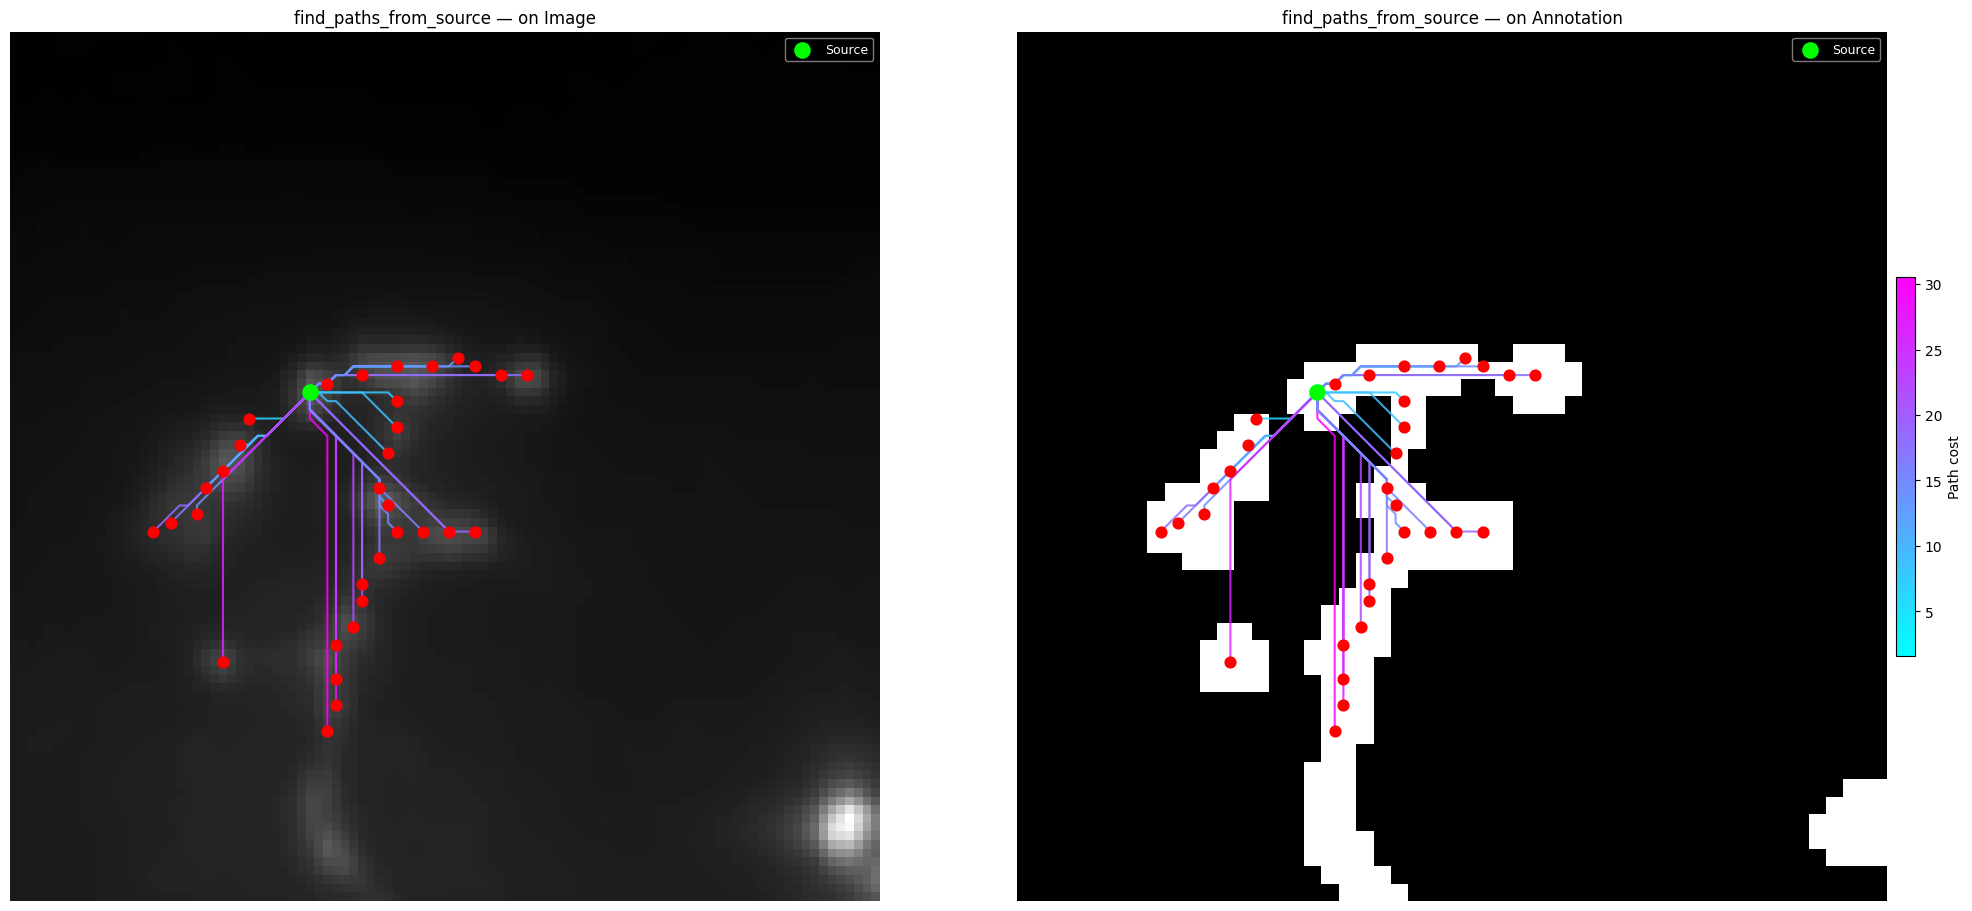

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(20, 9), constrained_layout=True)

for ax, bg, title in [
    (axes[0], roi_image,      'find_paths_from_source — on Image'),
    (axes[1], roi_annotation, 'find_paths_from_source — on Annotation'),
]:
    ax.imshow(bg, cmap='gray')
    ax.set_title(title)
    ax.axis('off')

    # Draw found paths, colour-coded by normalised cost
    costs = [v[1] for v in found.values()]
    norm = plt.Normalize(vmin=min(costs), vmax=max(costs)) if costs else plt.Normalize(0, 1)
    cmap_path = plt.cm.cool

    for target, (path, cost) in found.items():
        ys = [p[0] for p in path]
        xs = [p[1] for p in path]
        ax.plot(xs, ys, color=cmap_path(norm(cost)), linewidth=1.5, alpha=0.85)

    # Source
    ax.scatter(source[1], source[0], c='lime', s=120, zorder=6, label='Source')
    # Targets
    for t in found:
        ax.scatter(t[1], t[0], c='red', s=60, zorder=5)
    for t in not_found:
        ax.scatter(t[1], t[0], c='orange', s=60, zorder=5, marker='x')

    ax.legend(fontsize=9, loc='upper right', framealpha=0.6,
              facecolor='black', labelcolor='white')

sm = plt.cm.ScalarMappable(cmap=cmap_path, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=axes[1], fraction=0.02, pad=0.01, label='Path cost')
plt.show()

# find_paths_from_seeds — Batch Pairwise Path Finding

In [15]:
SEARCH_RADIUS = 40.0

labeled = np.asarray(ski.measure.label(roi_annotation, connectivity=2))


path_lookup = pathfinder.find_paths_from_seeds(
    topology_points=topology_points,
    kdtree=kdtree,
    search_radius=SEARCH_RADIUS,
    label_img=labeled,
)

print(f'Total paths found: {len(path_lookup)}')

costs = [v[1] for v in path_lookup.values()]
lengths = [len(v[0]) for v in path_lookup.values()]
print(pd.DataFrame({'cost': costs, 'path_length': lengths}).describe().to_string())

Total paths found: 458
             cost  path_length
count  458.000000   458.000000
mean    21.019539    24.432314
std      5.420975     6.593612
min      6.368806     8.000000
25%     17.382256    19.000000
50%     20.667175    24.000000
75%     24.593351    29.000000
max     33.079952    38.000000


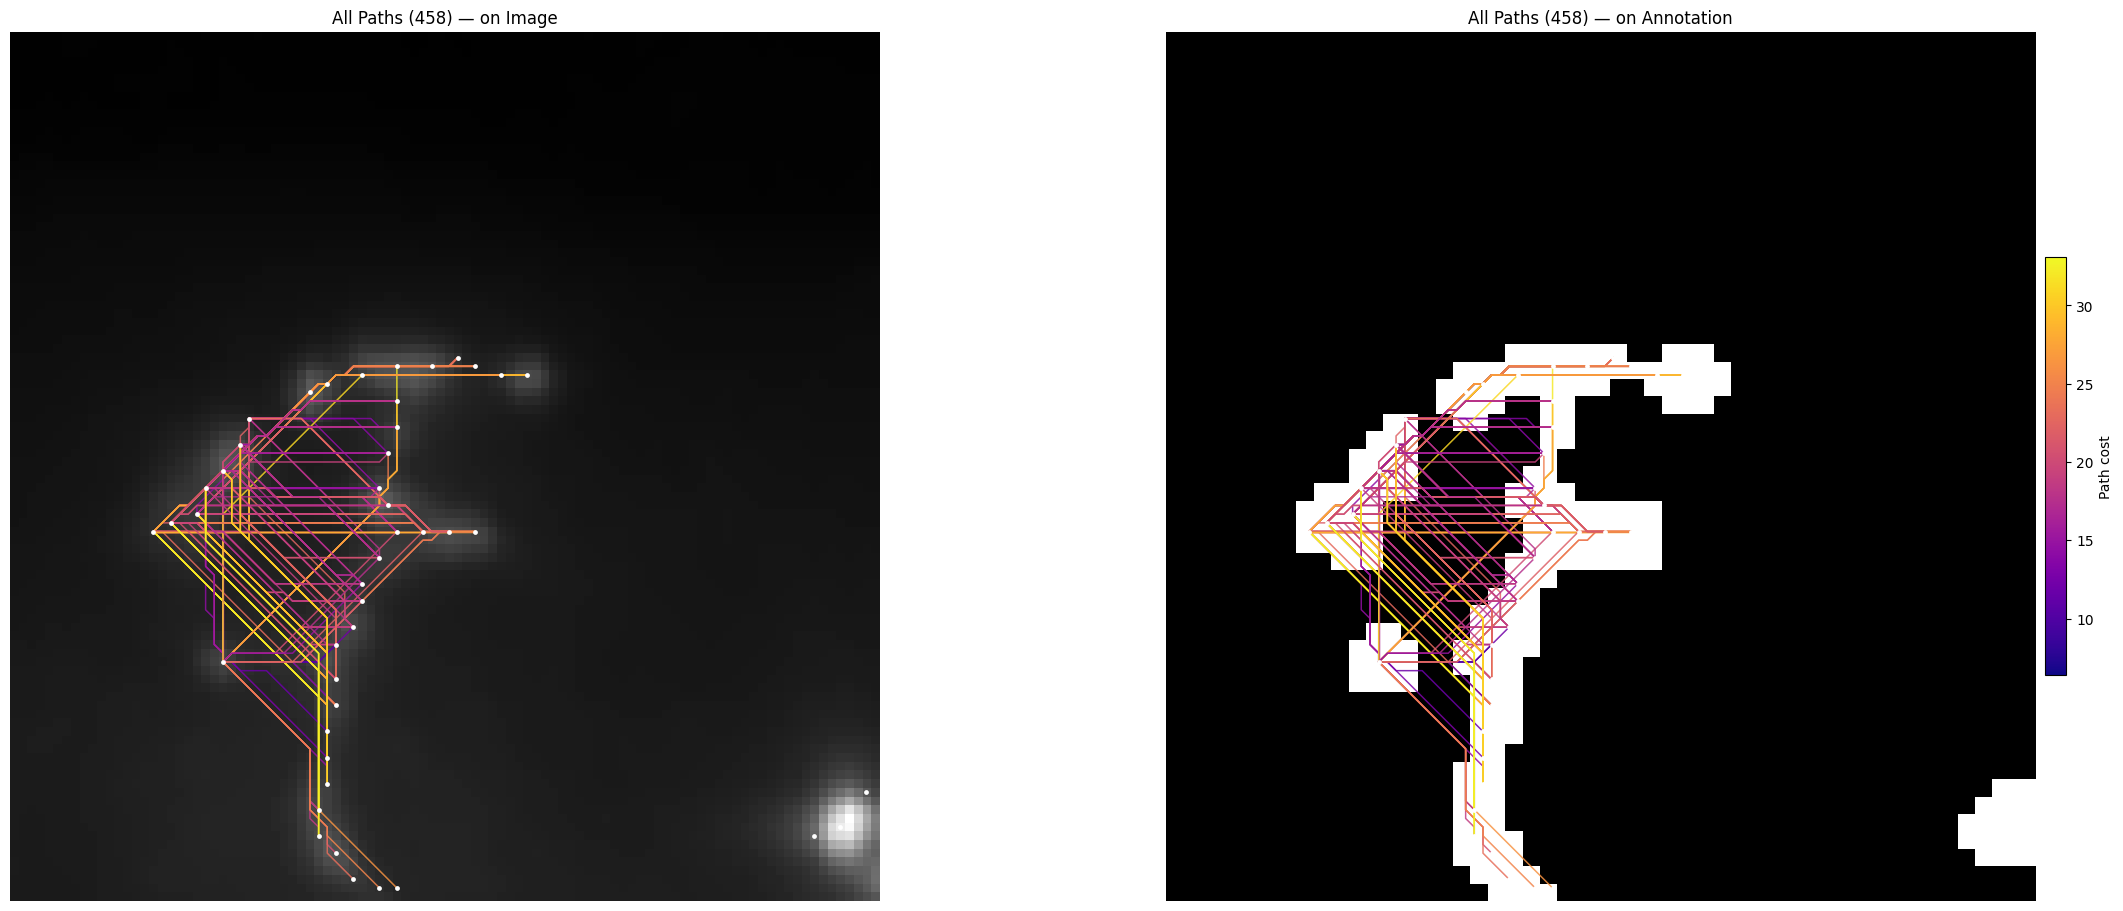

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(22, 9), constrained_layout=True)

all_costs = [v[1] for v in path_lookup.values()]
norm_all  = plt.Normalize(vmin=min(all_costs), vmax=max(all_costs))
cmap_all  = plt.cm.plasma

for ax, bg, title in [
    (axes[0], roi_image,      f'All Paths ({len(path_lookup)}) — on Image'),
    (axes[1], roi_annotation, f'All Paths ({len(path_lookup)}) — on Annotation'),
]:
    ax.imshow(bg, cmap='gray')
    ax.set_title(title)
    ax.axis('off')

    for (s, t), (path, cost) in path_lookup.items():
        ys = [p[0] for p in path]
        xs = [p[1] for p in path]
        ax.plot(xs, ys, color=cmap_all(norm_all(cost)), linewidth=1.0, alpha=0.6)

    # Seed nodes
    ax.scatter(topology_points[:, 1], topology_points[:, 0],
               c='white', s=12, zorder=5, linewidths=0)

sm = plt.cm.ScalarMappable(cmap=cmap_all, norm=norm_all)
sm.set_array([])
plt.colorbar(sm, ax=axes[1], fraction=0.02, pad=0.01, label='Path cost')
plt.show()

# Cost Threshold Analysis

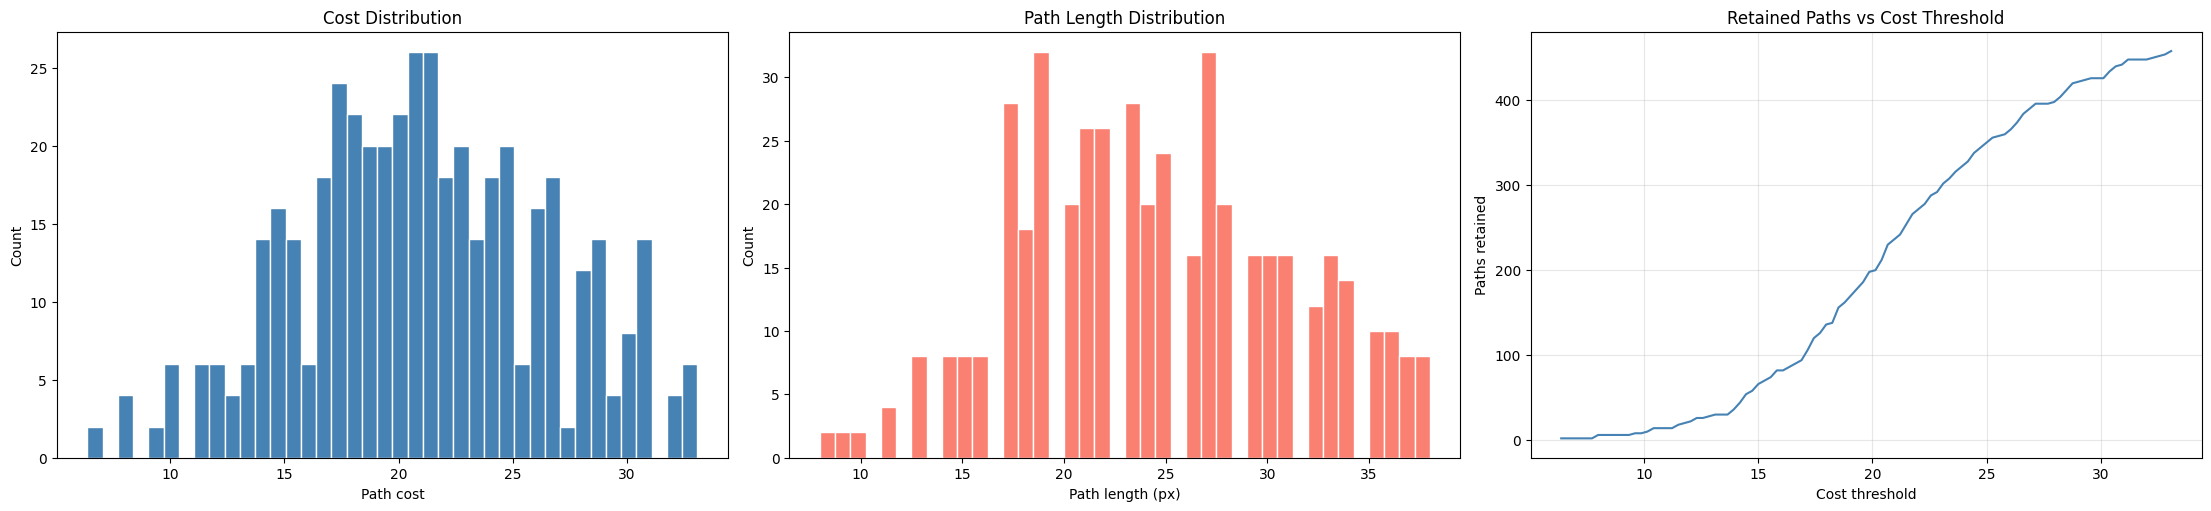

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(22, 5), constrained_layout=True)

# Cost distribution
axes[0].hist(all_costs, bins=40, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Path cost')
axes[0].set_ylabel('Count')
axes[0].set_title('Cost Distribution')

# Path length distribution
axes[1].hist(lengths, bins=40, color='salmon', edgecolor='white')
axes[1].set_xlabel('Path length (px)')
axes[1].set_ylabel('Count')
axes[1].set_title('Path Length Distribution')

# Retained paths vs cost threshold
thresholds = np.linspace(min(all_costs), max(all_costs), 100)
retained = [sum(1 for c in all_costs if c <= th) for th in thresholds]
axes[2].plot(thresholds, retained, color='steelblue')
axes[2].set_xlabel('Cost threshold')
axes[2].set_ylabel('Paths retained')
axes[2].set_title('Retained Paths vs Cost Threshold')
axes[2].grid(True, alpha=0.3)

plt.show()

# Search Radius Sensitivity

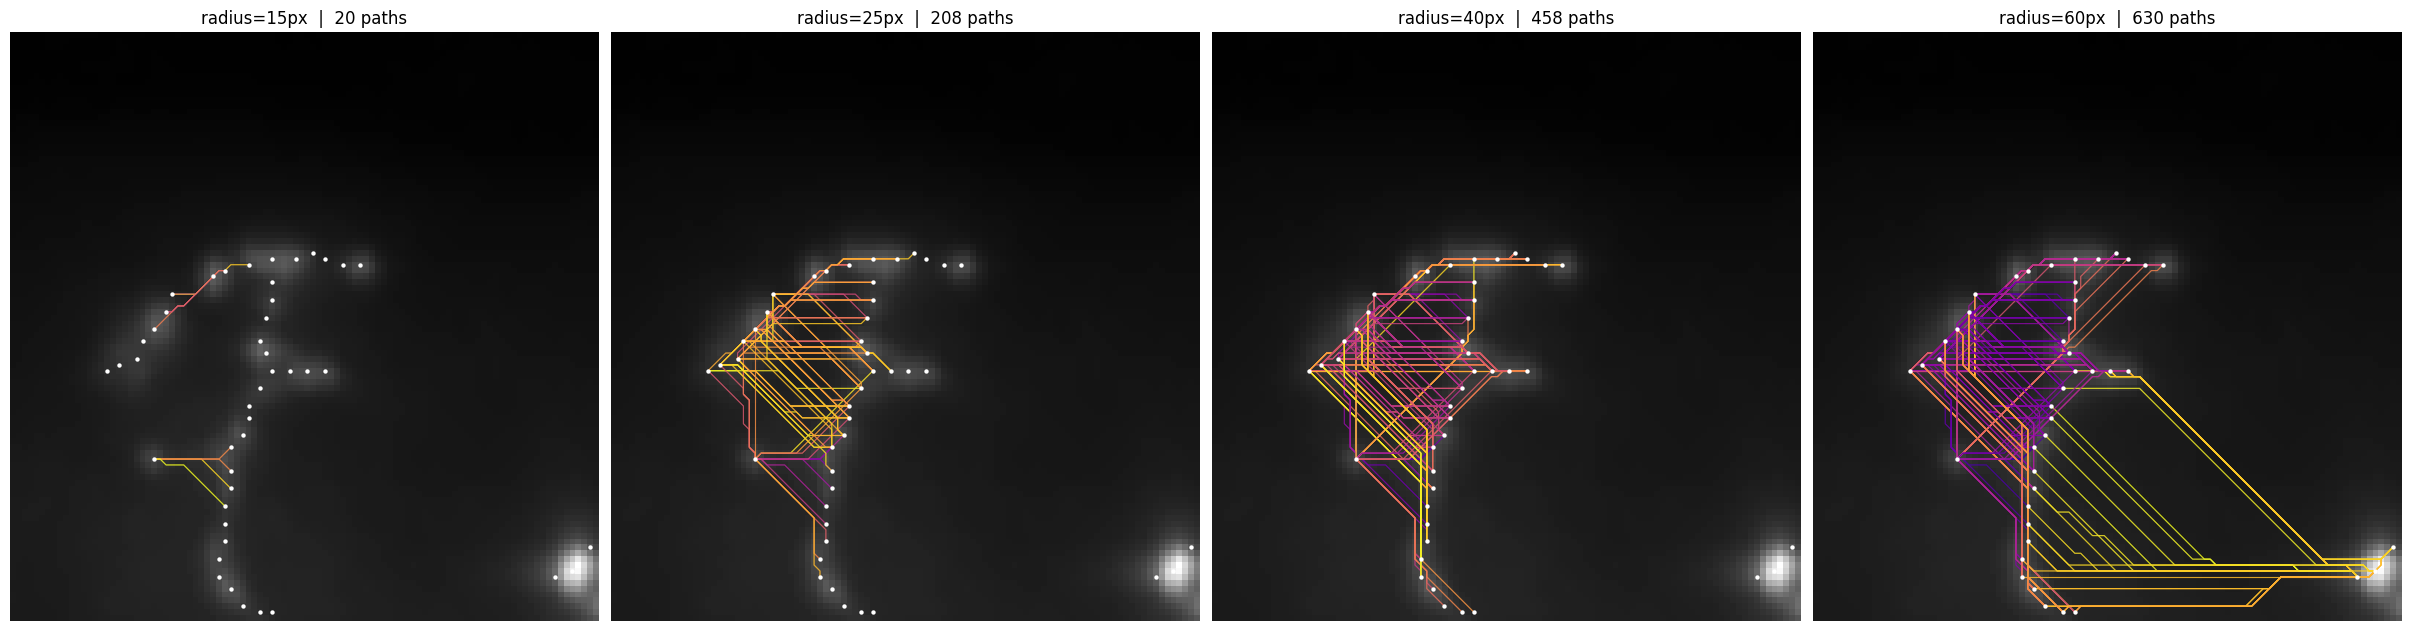

In [18]:
radii = [15, 25, 40, 60]
fig, axes = plt.subplots(1, len(radii), figsize=(24, 7), constrained_layout=True)

for ax, r in zip(axes, radii):
    pl = pathfinder.find_paths_from_seeds(
        topology_points=topology_points,
        kdtree=kdtree,
        search_radius=r,
        label_img=labeled,
    )
    r_costs = [v[1] for v in pl.values()]
    norm_r = plt.Normalize(vmin=min(r_costs) if r_costs else 0,
                           vmax=max(r_costs) if r_costs else 1)

    ax.imshow(roi_image, cmap='gray')
    ax.set_title(f'radius={r}px  |  {len(pl)} paths')
    ax.axis('off')

    for (s, t), (path, cost) in pl.items():
        ys = [p[0] for p in path]
        xs = [p[1] for p in path]
        ax.plot(xs, ys, color=plt.cm.plasma(norm_r(cost)), linewidth=0.8, alpha=0.6)

    ax.scatter(topology_points[:, 1], topology_points[:, 0],
               c='white', s=10, zorder=5, linewidths=0)

plt.show()